In [3]:
from math import sqrt


def dist_euclidiana(p, q):
    resultado = 0

    for item in zip(p, q):
        resultado += (item[0] - item[1]) ** 2
    
    return sqrt(resultado)

In [4]:

from collections import Counter


def knn_sem_moda(treino, rotulos, teste, k):
    rotulos_finais = []

    for dado in teste:
        distancias = []
        
        for i in range(len(treino)):
            distancias.append((dist_euclidiana(treino[i], dado), rotulos[i])) 

        distancias.sort(key=lambda x: x[0])

        distancias = distancias[:k]
        votos = [tuple(x[1]) for x in distancias]

        rotulo_principal = Counter(votos).most_common(1)[0][0]

        rotulos_finais.append(rotulo_principal)

    return rotulos_finais

    

In [5]:
### grupo de dados 1 (dataset iris)

import scipy.io as scipy

mat = scipy.loadmat('grupoDados1.mat')
grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn_sem_moda(grupoTrain, trainRots, grupoTest, 1)

estaCorreto = rotuloPrevisto == testRots

numCorreto = sum(estaCorreto)

totalNum = len(testRots)

acuracia = numCorreto / totalNum

print(acuracia)

[0.96]


In [6]:
from statistics import mode

def knn(treino, rotulos, teste, k):
    rotulos_finais = []

    for dado in teste:
        distancias = []
        
        for i in range(len(treino)):
            distancias.append((dist_euclidiana(treino[i], dado), rotulos[i])) 

        distancias.sort(key=lambda x: x[0])

        distancias = distancias[:k]
        votos = [tuple(x[1]) for x in distancias]

        rotulo_principal = mode(votos)

        rotulos_finais.append(rotulo_principal)

    return rotulos_finais

In [7]:
### grupo de dados 1 (dataset iris) - com mode

import scipy.io as scipy

mat = scipy.loadmat('grupoDados1.mat')
grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn(grupoTrain, trainRots, grupoTest, 10)

estaCorreto = rotuloPrevisto == testRots

numCorreto = sum(estaCorreto)

totalNum = len(testRots)

acuracia = numCorreto / totalNum

print(acuracia)

[0.94]


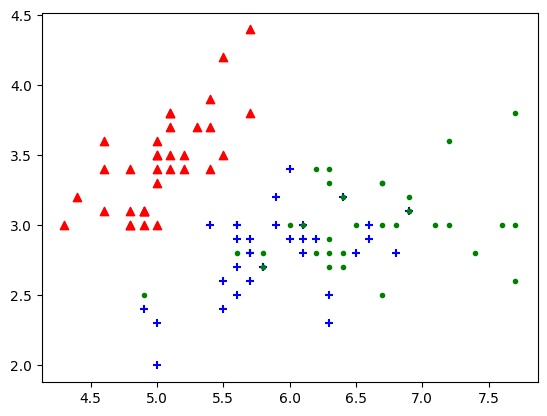

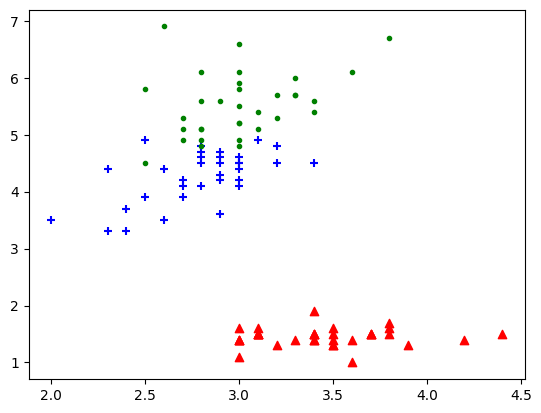

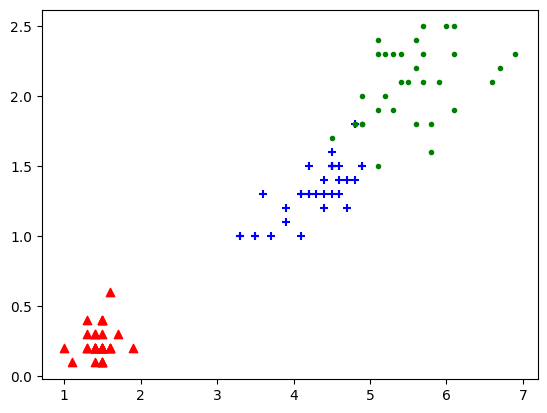

In [8]:
### grupo de dados 1 (dataset iris) - com mode - visualizacao
import matplotlib.pyplot as plt

def getDadosRotulo(dados, rotulos, rotulo, indice):
    ret = []

    for idx in range(0, len(dados)):
        if(rotulos[idx] == rotulo):
            ret.append(dados[idx][indice])        

    return ret



def visualizaPontos(dados, rotulos, d1, d2):
    fig, ax = plt.subplots() 

    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')  

    plt.show()

visualizaPontos(grupoTrain, trainRots, 0, 1)
visualizaPontos(grupoTrain, trainRots, 1, 2)
visualizaPontos(grupoTrain, trainRots, 2, 3)

## Grupo de Dados 1:
O grupoDados1 é um conjunto de dados de flores. Para mais informações consulte: http://archive.ics.uci.edu/ml/datasets/Iris .

### Q1.1. Qual é a acurácia máxima que você consegue da classificação?
(2, array([0.98]))

com k = 3 tivemos uma acurácia de 0.98, sendo esta a maior rodando de k = 0 até 100.

--> ver abaixo (código)

In [9]:
maior_acuracia = (0, 0)

for i in range(100):
    rotuloPrevisto = knn(grupoTrain, trainRots, grupoTest, i + 1)

    estaCorreto = rotuloPrevisto == testRots

    numCorreto = sum(estaCorreto)

    totalNum = len(testRots)

    acuracia = numCorreto / totalNum

    if (maior_acuracia[1] < acuracia):
        print(f"encontrada acurácia maior com k = {i + 1} =  {acuracia}")
        maior_acuracia = (i + 1, acuracia)

print("maior acuracia encontrada: ")
print(maior_acuracia)

encontrada acurácia maior com k = 1 =  [0.96]
encontrada acurácia maior com k = 3 =  [0.98]
maior acuracia encontrada: 
(3, array([0.98]))


### Q1.2. É necessário ter todas as características (atributos) para obter a acurácia máxima para esta classificação?
olhando os gráficos acima, é possível observar que os as features (2, 3) já fazem uma boa separação dos dados, assim, poderíamos em tese usar apenas elas.

testamos isso com o código abaixo e, usando apenas estas features, obtivemos a mesma acurácia, porém com um k maior.

isso pode ser devido a redundância de atributos (dois atributos estão muito correlacionados não adicionam informação nova)

In [10]:

testes_de_features = [
    ([2, 3], "pétalas (2, 3)"),
    ([0, 1], "sépalas (0, 1)"),
    ([1, 2], "misto (1, 2)")
]

for teste in testes_de_features:
    maior_acuracia = (0, 0)

    print(teste[1])
    for i in range(100):
        rotuloPrevisto = knn(grupoTrain[:, teste[0]], trainRots, grupoTest[:, teste[0]], i + 1)

        estaCorreto = rotuloPrevisto == testRots

        numCorreto = sum(estaCorreto)

        totalNum = len(testRots)

        acuracia = numCorreto / totalNum

        if (maior_acuracia[1] < acuracia):
            print(f"encontrada acurácia maior com k = {i + 1} =  {acuracia}")
            maior_acuracia = (i + 1, acuracia)

    print("maior acuracia encontrada: ")
    print(maior_acuracia)

pétalas (2, 3)
encontrada acurácia maior com k = 1 =  [0.94]
encontrada acurácia maior com k = 3 =  [0.96]
encontrada acurácia maior com k = 25 =  [0.98]
maior acuracia encontrada: 
(25, array([0.98]))
sépalas (0, 1)
encontrada acurácia maior com k = 1 =  [0.68]
encontrada acurácia maior com k = 3 =  [0.7]
encontrada acurácia maior com k = 5 =  [0.72]
encontrada acurácia maior com k = 8 =  [0.74]
encontrada acurácia maior com k = 9 =  [0.76]
encontrada acurácia maior com k = 12 =  [0.78]
maior acuracia encontrada: 
(12, array([0.78]))
misto (1, 2)
encontrada acurácia maior com k = 1 =  [0.9]
encontrada acurácia maior com k = 3 =  [0.96]
maior acuracia encontrada: 
(3, array([0.96]))


=======================================================

grupo de dados 2

Q2.1: Aplique seu kNN a este problema. Qual é a sua acurácia de classificação?

-> 68.3%

Q2.2: A acurácia pode ser igual a 98% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de tal forma que a acurácia se torne 98% e explique o que você fez e por quê.

-> fizemos análise gráfica/exploratória dos dados e vimos que as features 6 e 12 (flavonoides e prolina) separavam bastante os dados. fizemos o teste usando apenas essas duas features e chegamos numa acurácia de 93%. com essas duas features, fizemos um teste adicionando uma terceira (iteramos por todas elas) e vimos que adicionando a feature 9, intensidade de cor, chegamos numa acurácia de 100% com k = 10. para chegar na acurácia de 98%, poderíamos usar as features 0, 6 e 12 (álcool, flav. e prolina), com k = 6.

-> conversando com a professora, notamos que nossa implementação não estava no caminho certo, então refizemos com a normalização dos dados, o que gerou uma acurácia de 98% com k = 3.

In [11]:
### grupo de dados 2 (vinhos)

import scipy.io as scipy

mat = scipy.loadmat('grupoDados2.mat')
grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn_sem_moda(grupoTrain, trainRots, grupoTest, 1)

estaCorreto = rotuloPrevisto == testRots

numCorreto = sum(estaCorreto)

totalNum = len(testRots)

acuracia = numCorreto / totalNum

print(acuracia)

[0.68333333]


In [12]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


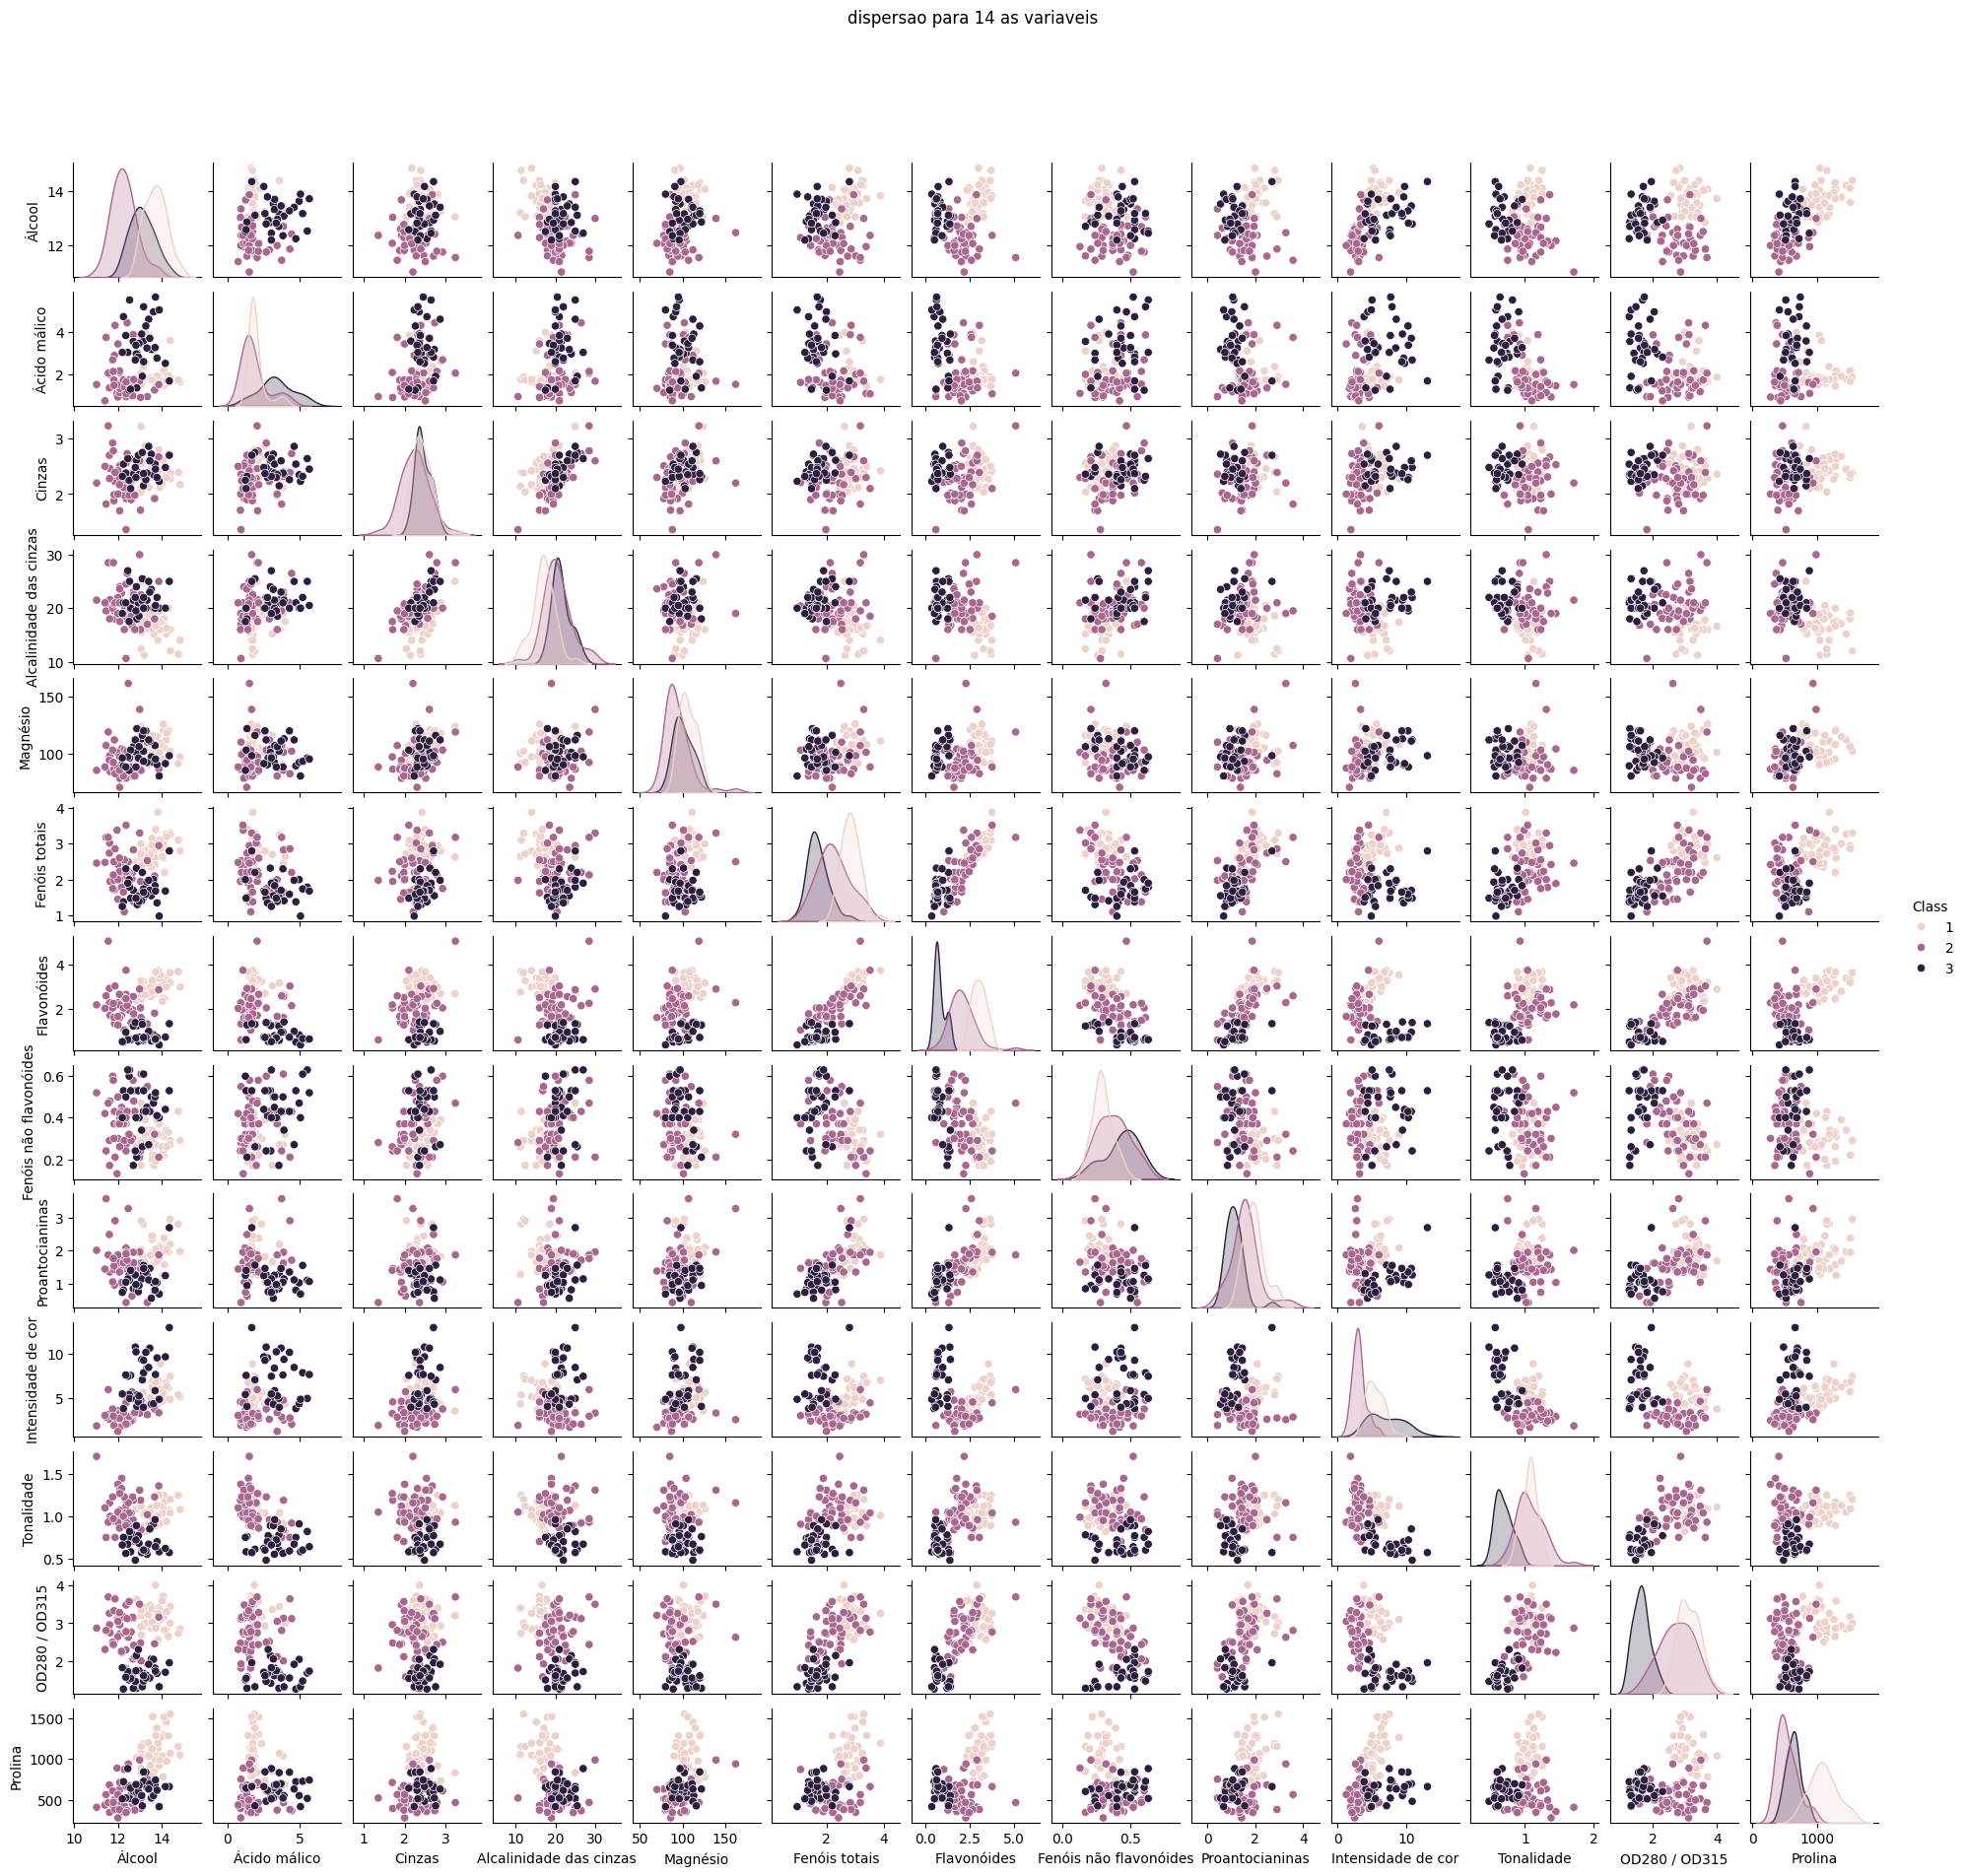

Graph created successfully!


In [13]:
# https://datascience.stackexchange.com/questions/14964/feature-selection-for-k-nearest-neighbour-and-decision-trees

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nomes_features = [
    "Álcool", "Ácido málico", "Cinzas", "Alcalinidade das cinzas", 
    "Magnésio", "Fenóis totais", "Flavonóides", "Fenóis não flavonóides", 
    "Proantocianinas", "Intensidade de cor", "Tonalidade", 
    "OD280 / OD315", "Prolina"
]

df = pd.DataFrame(grupoTrain, columns=nomes_features)
df['Class'] = np.array(trainRots).flatten()

g = sns.pairplot(df, hue="Class", height=1.5)

plt.subplots_adjust(top=0.9) 
g.fig.suptitle(f'dispersao para {len(df.columns)} as variaveis')

plt.show()
print("Graph created successfully!")

In [14]:
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()

X_train_reduzido = grupoTrain[:, (6, 12)]
X_test_reduzido = grupoTest[:, (6, 12)]

X_train_scaled = scaler.fit_transform(X_train_reduzido)
X_test_scaled = scaler.transform(X_test_reduzido)

maior_acuracia = (0, 0)

for i in range(100):
    rotuloPrevisto = knn(X_train_scaled, trainRots, X_test_scaled, i + 1)

    estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()

    numCorreto = sum(estaCorreto)

    totalNum = len(testRots)

    acuracia = numCorreto / totalNum

    if (maior_acuracia[1] < acuracia):
        print(f"encontrada acurácia maior com k = {i + 1} =  {acuracia:.4f}")
        maior_acuracia = (i + 1, acuracia)

print("\nMaior acuracia encontrada:")
print(f"K = {maior_acuracia[0]} com {maior_acuracia[1]*100:.1f}% de acerto")

encontrada acurácia maior com k = 1 =  0.9333

Maior acuracia encontrada:
K = 1 com 93.3% de acerto


In [15]:
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()

for i in range(12):
    X_train_reduzido = grupoTrain[:, (i, 6, 12)]
    X_test_reduzido = grupoTest[:, (i, 6, 12)]

    X_train_scaled = scaler.fit_transform(X_train_reduzido)
    X_test_scaled = scaler.transform(X_test_reduzido)

    maior_acuracia = (0, 0)

    for j in range(100):
        rotuloPrevisto = knn(X_train_scaled, trainRots, X_test_scaled, j + 1)

        estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()

        numCorreto = sum(estaCorreto)

        totalNum = len(testRots)

        acuracia = numCorreto / totalNum

        if (maior_acuracia[1] < acuracia):
            print(f"encontrada acurácia maior com k = {j + 1} =  {acuracia:.4f}")
            maior_acuracia = (j + 1, acuracia)

    print(f"({i}, 6, 12)")
    print("\nMaior acuracia encontrada:")
    print(f"K = {maior_acuracia[0]} com {maior_acuracia[1]*100:.1f}% de acerto")

encontrada acurácia maior com k = 1 =  0.9500
encontrada acurácia maior com k = 6 =  0.9833
(0, 6, 12)

Maior acuracia encontrada:
K = 6 com 98.3% de acerto
encontrada acurácia maior com k = 1 =  0.9333
encontrada acurácia maior com k = 3 =  0.9500
(1, 6, 12)

Maior acuracia encontrada:
K = 3 com 95.0% de acerto
encontrada acurácia maior com k = 1 =  0.9167
encontrada acurácia maior com k = 11 =  0.9333
encontrada acurácia maior com k = 26 =  0.9500
(2, 6, 12)

Maior acuracia encontrada:
K = 26 com 95.0% de acerto
encontrada acurácia maior com k = 1 =  0.9333
encontrada acurácia maior com k = 9 =  0.9500
encontrada acurácia maior com k = 26 =  0.9667
(3, 6, 12)

Maior acuracia encontrada:
K = 26 com 96.7% de acerto
encontrada acurácia maior com k = 1 =  0.8833
encontrada acurácia maior com k = 3 =  0.9333
(4, 6, 12)

Maior acuracia encontrada:
K = 3 com 93.3% de acerto
encontrada acurácia maior com k = 1 =  0.9167
encontrada acurácia maior com k = 12 =  0.9333
(5, 6, 12)

Maior acuraci

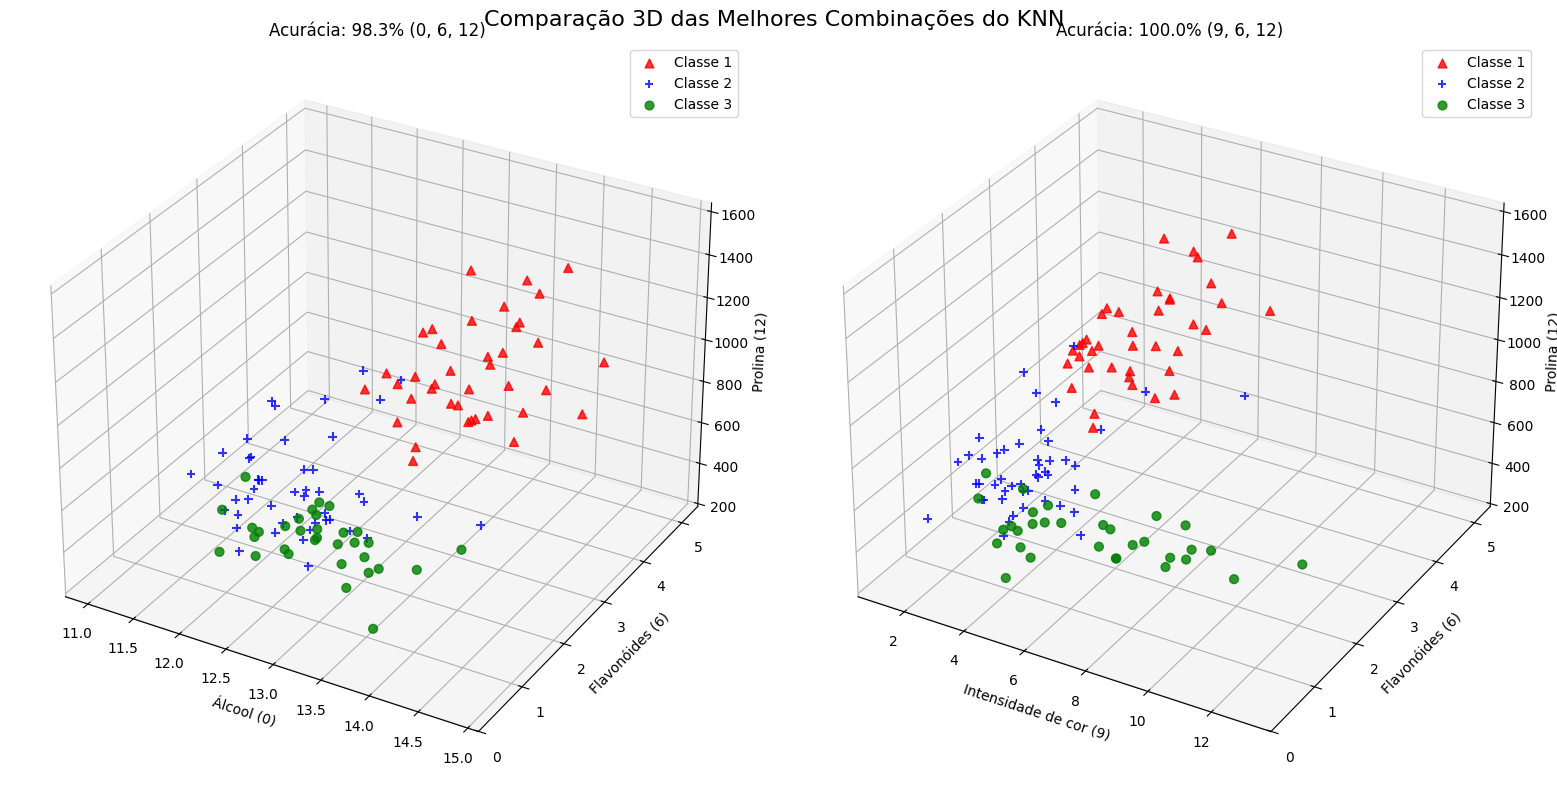

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

y = np.array(trainRots).flatten()
X = np.array(grupoTrain)

fig = plt.figure(figsize=(16, 8))

ax1 = fig.add_subplot(121, projection='3d')

for classe, cor, marcador in zip([1, 2, 3], ['red', 'blue', 'green'], ['^', '+', 'o']):
    idx_classe = (y == classe)
    ax1.scatter(X[idx_classe, 0], X[idx_classe, 6], X[idx_classe, 12], 
               c=cor, marker=marcador, label=f'Classe {classe}', s=40, alpha=0.8)

ax1.set_xlabel('Álcool (0)')
ax1.set_ylabel('Flavonóides (6)')
ax1.set_zlabel('Prolina (12)')
ax1.set_title('Acurácia: 98.3% (0, 6, 12)')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')

for classe, cor, marcador in zip([1, 2, 3], ['red', 'blue', 'green'], ['^', '+', 'o']):
    idx_classe = (y == classe)
    ax2.scatter(X[idx_classe, 9], X[idx_classe, 6], X[idx_classe, 12], 
               c=cor, marker=marcador, label=f'Classe {classe}', s=40, alpha=0.8)

ax2.set_xlabel('Intensidade de cor (9)')
ax2.set_ylabel('Flavonóides (6)')
ax2.set_zlabel('Prolina (12)')
ax2.set_title('Acurácia: 100.0% (9, 6, 12)')
ax2.legend()

plt.suptitle('Comparação 3D das Melhores Combinações do KNN', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(grupoTrain)
X_test_scaled = scaler.transform(grupoTest)

maior_acuracia = (0, 0.0)
for k in range(1, 101):
    rotuloPrevisto = knn(X_train_scaled, trainRots, X_test_scaled, k)
    estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()
    acuracia = estaCorreto.sum() / len(testRots)
    if acuracia > maior_acuracia[1]:
        maior_acuracia = (k, acuracia)
        print(f"encontrada acurácia maior com k = {k} = {acuracia:.4f}")

print(f"\nmelhor K após normalização: {maior_acuracia[0]} com acurácia = {maior_acuracia[1]*100:.2f}%")

encontrada acurácia maior com k = 1 = 0.9667
encontrada acurácia maior com k = 3 = 0.9833
encontrada acurácia maior com k = 14 = 1.0000

Melhor K após normalização: 14 com acurácia = 100.00%


=======================================================

grupo de dados 3

Q3.1: Aplique o kNN ao problema usando k = 1. Qual é a acurácia na classificação?

-> 70%

Q3.2: A acurácia pode ser igual a 92% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de tal forma que a acurácia se torne 92% e explique o que você fez e por quê.

-> encontramos uma acurácia de 92% utilizando k = 7 e fazendo a normalização dos dados (vimos que os dados da primeira coluna vão de 4.3 até 7.7, enquanto da segunda coluna de 0.1 até 2.5, o que afeta o cálculo da distância euclidiana). usamos o minmax scaling para colocar ambas as colunas num intervalo de 0 a 1.
-> encontramos uma acurácia ainda maior com k = 9 (de 94%), mas achamos ser um k muito alto para o volume de dados.


In [27]:
mat = scipy.loadmat('grupoDados3.mat')

grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn_sem_moda(grupoTrain, trainRots, grupoTest, 1)

estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()
acuracia = estaCorreto.sum() / len(testRots)

print(f"acurácia com k = 1 no grupo de dados 3: {acuracia:.4f}")

acurácia com k = 1 no grupo de dados 3: 0.7000


In [29]:
min_train = grupoTrain.min(axis=0)
max_train = grupoTrain.max(axis=0)

grupoTrain_adj = (grupoTrain - min_train) / (max_train - min_train)
grupoTest_adj = (grupoTest - min_train) / (max_train - min_train)

melhor = (None, 0.0, None)
k_maximo = min(100, len(grupoTrain_adj))

for k in range(1, k_maximo + 1):
    rp = knn_sem_moda(grupoTrain_adj, trainRots, grupoTest_adj, k)
    esta = np.array(rp).flatten() == np.array(testRots).flatten()
    acc = esta.sum() / len(testRots)
    if acc > melhor[1]:
        print(f"encontrada acurácia maior com k = {k} = {acc:.4f}")
        melhor = (k, acc, rp)

rotuloPrevisto = melhor[2]
print(f"melhor k encontrado: {melhor[0]} com acurácia = {melhor[1]:.4f}")

estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()
acuracia = estaCorreto.sum() / len(testRots)

print(f"acurácia com k = {melhor[0]} e dados normalizados: {acuracia:.4f}")

encontrada acurácia maior com k = 1 = 0.7000
encontrada acurácia maior com k = 4 = 0.8200
encontrada acurácia maior com k = 5 = 0.8400
encontrada acurácia maior com k = 6 = 0.8600
encontrada acurácia maior com k = 7 = 0.9200
encontrada acurácia maior com k = 9 = 0.9400
melhor k encontrado: 9 com acurácia = 0.9400
acurácia com k = 9 e dados normalizados: 0.9400


=======================================================

grupo de dados 4

Q4.1: Aplique seu algoritmo K-NN ao problema. Qual é a sua acurácia de classificação?
-> encontramos, com k = 4, uma acurácia de 77% (0.7667)

Q4.2: A acurácia pode chegar a 92% com o K-NN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou o valor de k de forma que a acurácia atinja 92% e explique o que você fez e por quê. Observe que, desta vez, há mais de um problema...

In [33]:
mat = scipy.loadmat('grupoDados4.mat')

grupoTest = mat['testSet']
grupoTrain = mat['trainSet']
trainRots = mat['trainLabs']
testRots = mat['testLabs']

melhor = (None, 0.0, None)
k_maximo = min(100, len(grupoTrain))
for k in range(1, k_maximo + 1):
    rotuloPrevisto = knn_sem_moda(grupoTrain, trainRots, grupoTest, k)

    estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()
    acuracia = estaCorreto.sum() / len(testRots)

    if acuracia > melhor[1]:
        print(f"encontrada acurácia maior com k = {k} = {acuracia:.4f}")
        melhor = (k, acuracia, rotuloPrevisto)

print(f"melhor k encontrado: {melhor[0]} com acurácia = {melhor[1]:.4f}")

encontrada acurácia maior com k = 1 = 0.7167
encontrada acurácia maior com k = 4 = 0.7667
melhor k encontrado: 4 com acurácia = 0.7667


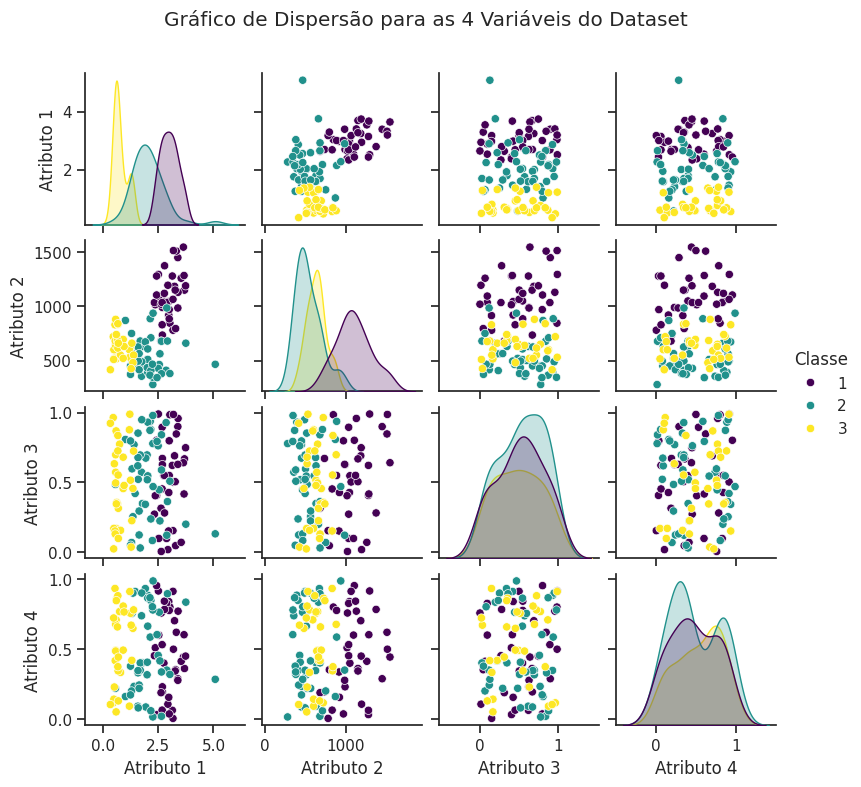

In [34]:
import scipy.io
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = scipy.io.loadmat('grupoDados4.mat')
X_train = data['trainSet']
y_train = data['trainLabs'].ravel()

nomes_features = ["Atributo 1", "Atributo 2", "Atributo 3", "Atributo 4"]

df = pd.DataFrame(X_train, columns=nomes_features)
df['Classe'] = y_train

sns.set_theme(style="ticks")
g = sns.pairplot(df, hue="Classe", palette="viridis", height=2.0)

plt.subplots_adjust(top=0.9)
g.fig.suptitle(f'Gráfico de Dispersão para as {len(nomes_features)} Variáveis do Dataset')

plt.show()

In [ ]:
# pelo gráfico acima, conseguimos perceber que alguns problemas:
# o atributo 2 tem uma escala muito diferente dos outros, o que pode prejudicar o knn
# além disso, os atributos 3 e 4 parecem ter uma distribuição muito similar, o que pode indicar ruído ou redundância

# o mais interessante seria tentar normalizar os dados e testar o knn novamente, para ver se a acurácia melhora

In [46]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# removendo os atributos 3 e 4 para tentar reduzir o ruído e a redundância
grupoTrain_reduzido = grupoTrain[:, :2]
grupoTest_reduzido = grupoTest[:, :2]

# normalização para resolver o problema da escala do atributo 2
scaler = StandardScaler()
grupoTrain_norm = scaler.fit_transform(grupoTrain_reduzido)
grupoTest_norm = scaler.transform(grupoTest_reduzido)

melhor = (None, 0.0, None)
k_maximo = min(100, len(grupoTrain_norm))

print("Iniciando busca com dados normalizados e seleção de atributos...\n")

for k in range(1, k_maximo + 1):
    rotuloPrevisto = knn_sem_moda(grupoTrain_norm, trainRots, grupoTest_norm, k)

    estaCorreto = np.array(rotuloPrevisto).flatten() == np.array(testRots).flatten()
    acuracia = estaCorreto.sum() / len(testRots)

    if acuracia > melhor[1]:
        print(f"Nova melhor acurácia: k = {k} -> {acuracia:.4f}")
        melhor = (k, acuracia, rotuloPrevisto)

print("-" * 30)
print(f"RESULTADO FINAL:")
print(f"Melhor k: {melhor[0]}")
print(f"Acurácia Máxima: {melhor[1]:.4f}")

Iniciando busca com dados normalizados e seleção de atributos...

Nova melhor acurácia: k = 1 -> 0.9333
------------------------------
RESULTADO FINAL:
Melhor k: 1
Acurácia Máxima: 0.9333
